# **Notebook 01: Data and Domain Setup**

**Description:** This notebook builds the official run's controlled Natural Questions and TechQA data foundation with annotation-based Natural Questions labels, deterministic corpora, and outcome-independent grouped train, validation, and test cohorts.

**Main Questions This Notebook Should Answer:**

- Which records have valid short-answer, retrieval-only, or benchmark-unanswerable supervision?
- Do both domains satisfy the shared schema and controlled local-corpus contract?
- Are duplicate questions and shared Natural Questions pages confined to one frozen split?
- What saved artifacts define the official run?

---

# **Part 1: Setup and Local Data Contract**

### **Environment Setup**


In [7]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / 'src/adaptive_rag').is_dir() and (p / 'config').is_dir())
sys.path.insert(0, str(REPO_ROOT / 'src'))
ROOT = Path(os.environ.get('ADAPTIVE_RAG_PROJECT_ROOT', REPO_ROOT)).resolve()
from adaptive_rag.luna_v2.common import load_config, load_table, read_json, save_table
cfg = load_config(ROOT)

### **Figure Export Helper**


In [8]:
FIGURES = cfg['paths']['artifacts'] / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 24)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print('Run:', cfg['version'], '| model:', cfg['generation']['model'])
print('Outputs:', cfg['paths']['artifacts'].relative_to(ROOT))

Run: luna-v2 | model: gpt-5.6-luna
Outputs: artifacts\luna_v2


### **Run Setup Interpretation**

The run uses the frozen luna-v2 configuration with gpt-5.6-luna, and exports figures with its experiment artifacts. This shared setup lets the later notebooks use the same model and output locations when comparing retrieval and generation strategies.

---

# **Part 2: Load, Normalize, and Freeze Cohorts**


### **Annotation-Based Labels and Corpus Construction**

Build or verify the cached Luna v2 QA, document, and cohort tables.

In [9]:
from adaptive_rag.luna_v2.dataset import prepare_data
qa, docs, cohort = prepare_data(cfg)
display(qa.groupby(['domain', 'annotation_category', 'generation_eligible']).size().rename('examples').reset_index())
display(docs.groupby('domain').size().rename('corpus_documents').to_frame())

,domain,annotation_category,generation_eligible,examples
0,natural_questions,long_only,False,130
1,natural_questions,no_positive_annotation,False,501
2,natural_questions,short_or_yes_no,True,369
3,techqa,answerable,False,2
4,techqa,answerable,True,608
5,techqa,benchmark_unanswerable,True,300


,corpus_documents
domain,
natural_questions,5000
techqa,5000


### **Reference Coverage and Split Integrity**

Keep long-only and negative-page examples visible while limiting primary generation to valid reference-bearing rows.

In [10]:
coverage = qa.assign(has_gold=qa.gold_document_ids.map(len).gt(0))
display(coverage.groupby('domain').agg(sampled=('example_id', 'size'),
    retrieval_eligible=('has_gold', 'sum'), generation_eligible=('generation_eligible', 'sum')))
display(cohort.groupby(['domain', 'split', 'answerable']).size().rename('examples').reset_index())
assert not cohort.example_id.duplicated().any()
nq = cohort[cohort.domain.eq('natural_questions')]
assert nq.groupby('split_group').split.nunique().max() == 1
assert set(cohort[cohort.split.eq('train')].domain) == {'natural_questions'}

,sampled,retrieval_eligible,generation_eligible
domain,,,
natural_questions,1000,499,369
techqa,910,610,908


,domain,split,answerable,examples
0,natural_questions,nq_test,True,74
1,natural_questions,train,True,221
2,natural_questions,validation,True,74
3,techqa,techqa_test,False,300
4,techqa,techqa_test,True,608


### **Cohort and Split Interpretation**

Natural Questions has 499 retrieval-eligible records but only 369 with short/yes-no supervision for generation. The 130 long-only records remain useful for retrieval analysis; the 501 records without positive annotations are not treated as proven unanswerable questions. TechQA contributes 908 generation-eligible examples: 608 answerable and 300 benchmark-unanswerable.

The 369 NQ generation examples are grouped into 221 training, 74 validation, and 74 test examples. All 908 TechQA examples remain in the target test split. The split checks confirm that duplicate-question/page groups do not cross NQ splits and that target-domain questions are absent from source training.

---

# **Part 3: Data Quality and Domain Analysis**

### **Question and Reference Length Distributions**

Inspect domain differences without using target-domain outcomes for policy development.

question_words                                            \
                           count  mean   std  min   25%   50%   75%    max   
domain                                                                       
natural_questions         1000.0   9.1   1.7  6.0   8.0   9.0  10.0   17.0   
techqa                     910.0  52.3  31.2  2.0  32.0  44.0  63.0  259.0   

                  reference_words                                           
                            count  mean   std  min  25%   50%   75%    max  
domain                                                                      
natural_questions          1000.0   1.9   4.9  0.0  0.0   0.0   2.0   64.0  
techqa                      910.0  31.3  36.1  0.0  1.0  21.0  48.8  302.0

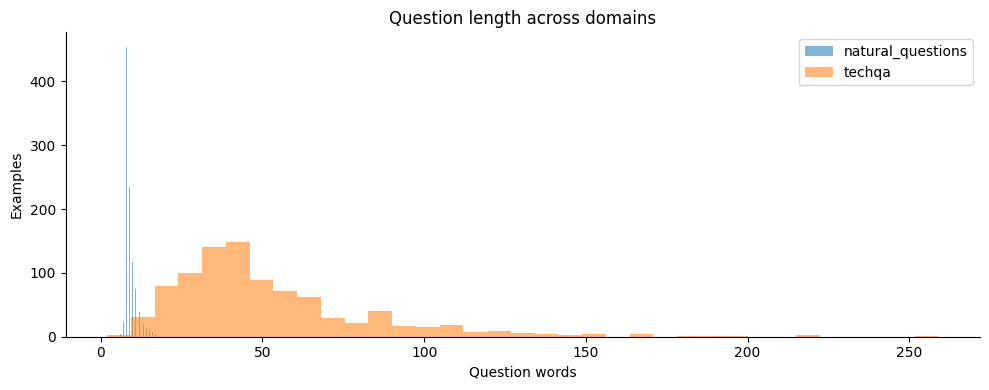

In [11]:
lengths = qa.assign(question_words=qa.question.str.split().map(len),
                    reference_words=qa.answer.fillna('').str.split().map(len))
display(lengths.groupby('domain')[['question_words', 'reference_words']].describe().round(1))
fig, ax = plt.subplots()
for domain, group in lengths.groupby('domain'):
    ax.hist(group.question_words, bins=35, alpha=.55, label=domain)
ax.set(xlabel='Question words', ylabel='Examples', title='Question length across domains')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / '01_question_lengths.png', dpi=160)
plt.show()

### **Dataset Manifest and Provenance**


In [12]:
display(read_json(cfg['paths']['processed'] / 'dataset_manifest.json'))

{'signature': 'd4e580fcb1abb10fd8c9b1bfb93f62015f0a05c85e62bd7992436f9ad1bc52e8',
 'table_sha256': {'qa': '7c4df3bb8196ac448fb5c728624bcd2aa01af9564257e59346f6a29f9c2a2e31',
  'docs': '466dbb6a495783711437545d9ecfd14385e4b78d3f93897582219edd09f997f4',
  'cohort': '479c601e21fb4a3ea326bcd5c9f76e200ac0dc2b97c5957d6a9fae60ee10b026'},
 'versions': {'python': '3.11.14',
  'openai': '3.3.1',
  'pandas': '3.0.2',
  'numpy': '2.2.6',
  'scikit-learn': '1.8.0',
  'sentence-transformers': '5.3.0',
  'torch': '2.11.0+cu128'},
 'source_files': ['data\\raw\\natural_questions\\simplified-nq-train.jsonl',
  'data\\raw\\techqa\\technote_corpus\\full_technote_collection.sections.json',
  'data\\raw\\techqa\\training_and_dev\\dev_Q_A.json',
  'data\\raw\\techqa\\training_and_dev\\training_dev_technotes.json',
  'data\\raw\\techqa\\training_and_dev\\training_dev_technotes.sections.json',
  'data\\raw\\techqa\\training_and_dev\\training_Q_A.json',
  'data\\raw\\techqa\\validation\\validation_example_outpu

### **Data Audit Interpretation**

TechQA questions average 52.3 words compared with 9.1 for NQ, and its references average 31.3 words compared with 1.85. The transfer evaluation changes question length and answer format as well as subject matter. Text vocabularies and source reference vectors remain fitted only on the frozen NQ training split.

---

# **Part 4: Conclusion**

This notebook created an auditable population of 1,910 sampled questions and 10,000 fixed documents. Of 1,000 NQ records, 369 short/yes-no examples entered generation, while 130 long-only and 501 no-positive records remained outside the primary answer experiment. The final 1,277-example generation cohort contains 369 NQ examples split into 221 train, 74 validation, and 74 test, plus 908 TechQA examples with 608 answerable and 300 unanswerable. These frozen IDs, document sets, and grouped splits provide the leakage-controlled handoff used by every later notebook.

---